# Kwant — Theory and Practice · Chapter 6
## Magnetic fields — Peierls substitution, Landau levels, the Hofstadter butterfly

*Part I · Section 14 · Figures 29–33* &nbsp;·&nbsp; [← Chapter 5](05_KPM_and_Continuum.ipynb) · [Contents](00_Contents.ipynb) · [Chapter 7 →](07_Solvers_Pitfalls_and_Exercises_I.ipynb)

### In this chapter

- [14. Magnetic fields — Peierls substitution and Landau levels](#14.-Magnetic-fields-—-Peierls-substitution-and-Landau-levels)
    - [The Peierls substitution](#The-Peierls-substitution)
    - [Landau levels](#Landau-levels)

Run the **Setup** cell first: it imports Kwant, reports the sparse solver, mutes three library warnings and defines `show_fig`, whose figure counter continues the course-wide numbering. Each chapter is self-contained given its Setup cell (a *carried over* cell, where present, rebuilds an object defined in an earlier chapter). Installation, the `kwant` kernel and the conventions are in [`00_Contents.ipynb`](00_Contents.ipynb).

`SPDX-License-Identifier: Apache-2.0` — Copyright 2026 Fabio Campolim.


In [1]:
# --- Setup: run this cell first ----------------------------------------------
# Imports, the sparse-solver report, three muted library warnings, and the
# figure helper.  Every chapter of the course starts with this cell.
import kwant
import numpy as np
import scipy
import tinyarray as ta                   # noqa: F401  (used by later cells)
import matplotlib
from matplotlib import pyplot

print("kwant", kwant.__version__, "| numpy", np.__version__,
      "| scipy", scipy.__version__, "| matplotlib", matplotlib.__version__)

# Which sparse solver is active? MUMPS is much faster than SciPy's SuperLU.
import kwant.solvers.default
print("default solver:", kwant.solvers.default.__name__)
try:
    import kwant.solvers.mumps          # noqa: F401
    print("MUMPS available: yes")
except ImportError:
    print("MUMPS available: no  (falling back to scipy sparse -> slower)")

matplotlib.rcParams['figure.figsize'] = (7, 5)

# Mute three library warnings that are not ours to fix and would otherwise be
# printed under some figures.  Done by wrapping warnings.showwarning rather than
# with warnings.filterwarnings(), because kwant.plotter calls
# warnings.resetwarnings() on every 3D plot, which silently deletes all user
# filters (reported upstream).  Only these three messages are muted:
#  * kwant 1.5.0's 3D plotter calls a matplotlib function deprecated in 3.10
#    (fixed on Kwant's main branch, unreleased);
#  * mpmath (via sympy) uses a deprecated bitcount helper;
#  * kwant.plotter.map notes that a few density values exceed the colour range,
#    which is expected for the delta-like densities in sections 6 and 12.
import warnings
_MUTED = ('proj_transform_clip', 'bitcount function is deprecated', 'overflowing upper limit')
_showwarning = warnings.showwarning

def _quiet_showwarning(message, category, filename, lineno, file=None, line=None):
    if not any(k in str(message) for k in _MUTED):
        _showwarning(message, category, filename, lineno, file, line)

warnings.showwarning = _quiet_showwarning

# --- Figure helper ------------------------------------------------------------
# Every figure ends with show_fig("..."), which stamps an auto-numbered italic
# caption under the figure and then shows it.  Figures are numbered
# continuously across the chapters of the course: this chapter's figures are
# 29–33, so the counter starts at 28.  (Re-running a single cell out of
# order advances it -- harmless, but numbers shift.)
_FIG_NO = [28]

def show_fig(caption=None):
    if caption:
        _FIG_NO[0] += 1
        fig = pyplot.gcf()
        fig.text(0.5, -0.02, f"Figure {_FIG_NO[0]}: {caption}",
                 ha='center', va='top', fontsize=9, style='italic',
                 wrap=True, transform=fig.transFigure)
    pyplot.show()


kwant 1.5.0 | numpy 2.5.1 | scipy 1.18.0 | matplotlib 3.10.7
default solver: kwant.solvers.default
MUMPS available: yes


---
## 14. Magnetic fields — Peierls substitution and Landau levels

### The Peierls substitution

A magnetic field enters a tight-binding model through the **phase** picked up by an
electron hopping between sites:

$$t_{ij} \;\longrightarrow\; t_{ij}\,\exp\!\left(-\frac{ie}{\hbar}\int_{\mathbf{r}_j}^{\mathbf{r}_i}\mathbf{A}\cdot d\boldsymbol{\ell}\right).$$

The physical content is gauge-invariant: the phase around any closed plaquette equals
$2\pi \Phi/\Phi_0$, the flux through it in units of the flux quantum. In the Landau gauge
$\mathbf{A} = (-By, 0, 0)$ this is a $y$-dependent phase on $x$-hoppings:

```python
def hopx(to_site, from_site, B):
    y = from_site.tag[1]
    return -t * np.exp(-1j * B * y)
```

**Discretisation constraint**: the flux per plaquette must be small, $Ba^2 \ll \Phi_0$,
or you leave the continuum regime and enter Hofstadter physics — which is fine if intended,
but not if you meant to model a smooth field.

Kwant 1.4 added `kwant.physics.magnetic_gauge`, which computes a consistent gauge
automatically for arbitrary geometries — much safer than hand-rolling a gauge on a
non-trivial shape, where a naive choice can break the lead's translational symmetry.

> **Version pitfall (checked 2026-08-28).** With **kwant 1.5.0 and numpy ≥ 2.5** (released
> 2026-06-21), `magnetic_gauge` raises
> `ValueError: Both input arrays must be (arrays of) 3-dimensional vectors` for every
> 2D system: `kwant/physics/gauge.py` calls `np.cross` on 2-vectors, a use NumPy removed in
> 2.5. The fix has been on Kwant's `main` branch since January 2025 but is not in any
> release. Until a 1.5.1 appears, pin `numpy<2.5` if you need `magnetic_gauge`; the
> hand-rolled Peierls phases used in this notebook are unaffected.

### Landau levels

In an infinite 2D system the field quenches the kinetic energy into flat, massively
degenerate **Landau levels** $E_n = \hbar\omega_c(n + 1/2)$, $\omega_c = eB/m$.

`kwant.continuum.discretize_landau` builds a system in the **Landau-level basis** directly
rather than on a real-space lattice: translational symmetry perpendicular to the field is
used to reduce the problem, with `N` the number of levels retained. This is *far* cheaper
than a real-space lattice for strong fields, and is the right tool for spectra vs $B$.

*Further reading:* the lattice problem at rational flux is the Hofstadter
butterfly, PRB **14**, 2239 (1976).  The quantum Hall effect itself:
K. v. Klitzing *et al.*, PRL **45**, 494 (1980); the edge-state picture,
B. I. Halperin, PRB **25**, 2185 (1982); the gauge argument for exact
quantisation, R. B. Laughlin, PRB **23**, 5632 (1981).


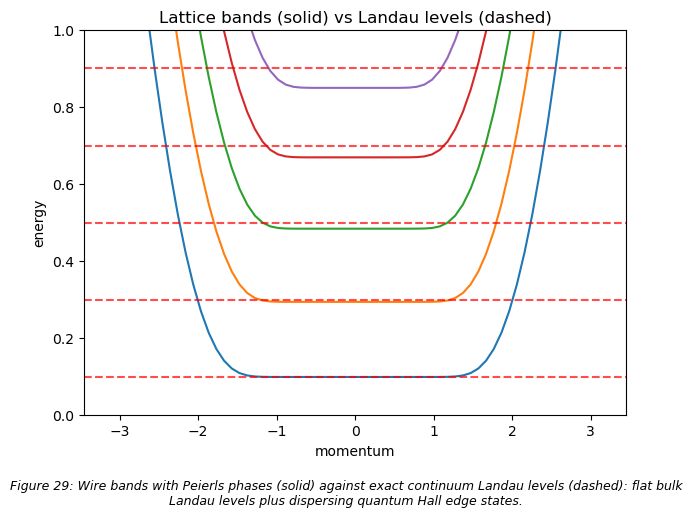

In [2]:
# --- Peierls phases on a lattice, versus exact Landau levels -----------------
import kwant, kwant.continuum, numpy as np, scipy.linalg
from matplotlib import pyplot

lat = kwant.lattice.square(norbs=1)

def peierls(to_site, from_site, B):
    y = from_site.tag[1]
    return -1 * np.exp(-1j * B * y)

wire = kwant.Builder(kwant.TranslationalSymmetry((-1, 0)))
wire[(lat(0, j) for j in range(-19, 20))] = 4
wire[lat.neighbors()] = -1
wire[kwant.HoppingKind((1, 0), lat)] = peierls
fwire = wire.finalized()

# the same physics in the Landau-level basis
landau_syst = kwant.continuum.discretize_landau("k_x**2 + k_y**2", N=5).finalized()

fig, ax = pyplot.subplots(1, 1)
params = dict(B=0.1)
kwant.plotter.bands(fwire, ax=ax, params=params)

h = landau_syst.hamiltonian_submatrix(params=params)
for ev in scipy.linalg.eigvalsh(h):
    ax.axhline(ev, linestyle='--', color='r', alpha=.7)

ax.set_xlabel("momentum"); ax.set_ylabel("energy")
ax.set_ylim(0, 1)
ax.set_title("Lattice bands (solid) vs Landau levels (dashed)")
show_fig(r'Wire bands with Peierls phases (solid) against exact continuum Landau levels (dashed): flat bulk Landau levels plus dispersing quantum Hall edge states.')

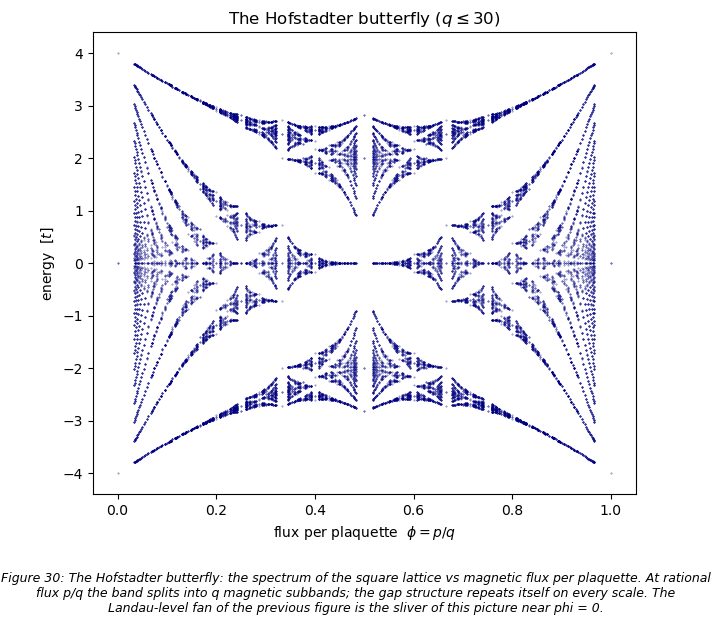

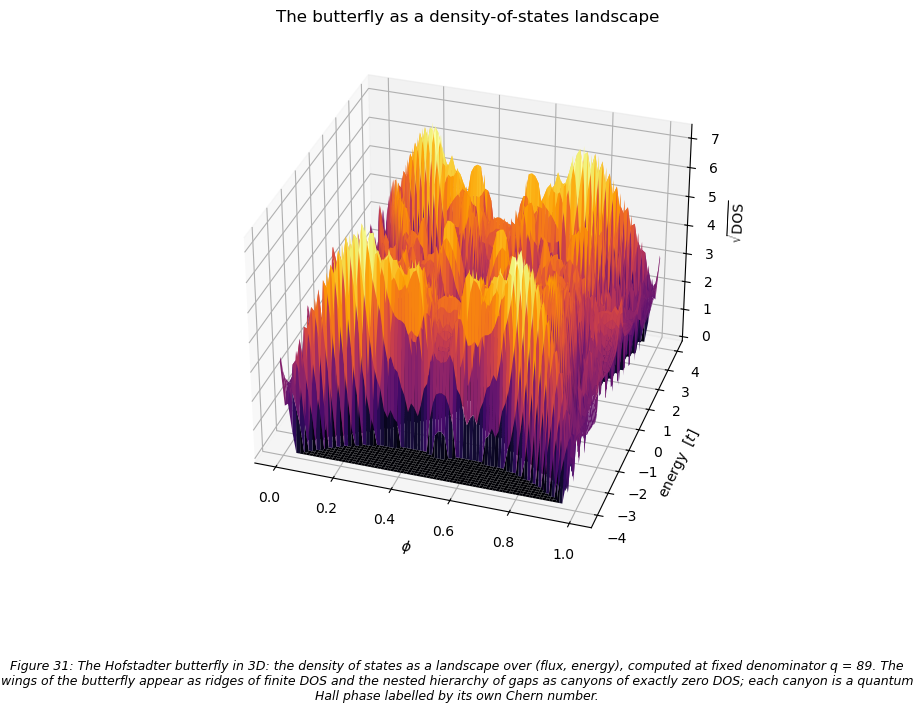

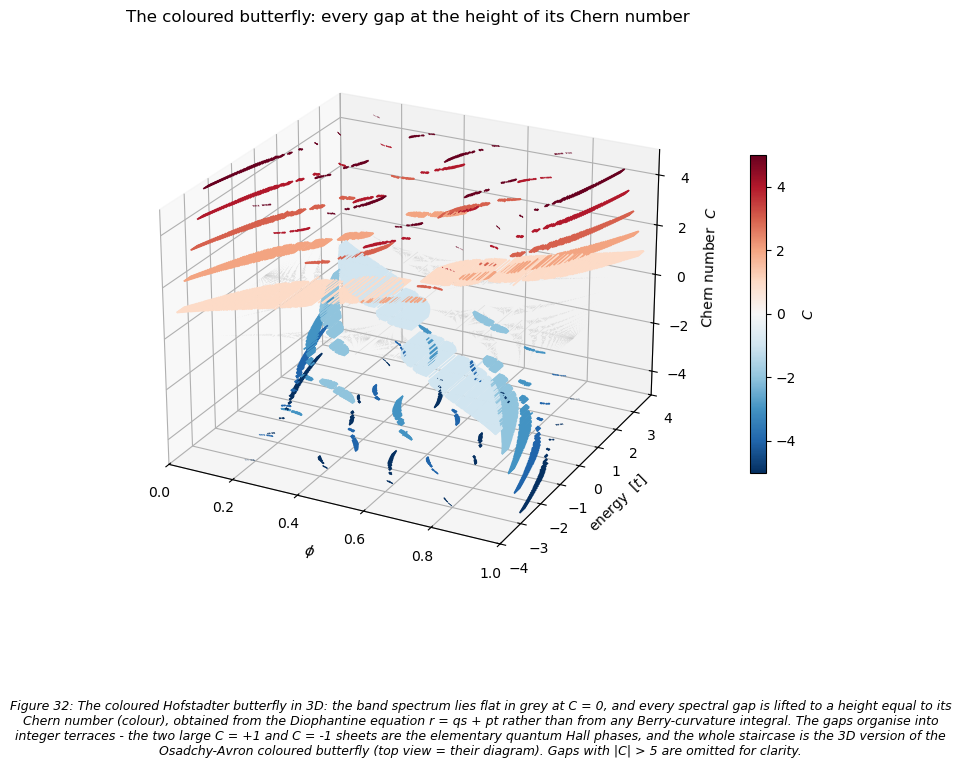

In [3]:
# --- The Hofstadter butterfly, flat and in 3D ---------------------------------
# At rational flux phi = p/q per plaquette, the magnetic translation group
# splits the tight-binding band into q magnetic subbands.  The spectrum as a
# function of flux is the Hofstadter butterfly [PRB 14, 2239 (1976)]: a
# a spectrum whose gap structure recurs at every scale, and every gap inside it carries a quantised Hall conductance (the
# TKNN integers of Part II).
import numpy as np
from matplotlib import pyplot

def harper(p, q, k1, k2):
    """The q x q magnetic Bloch Hamiltonian of the square lattice (t = 1)."""
    m = np.arange(q)
    H = np.diag(2 * np.cos(k2 + 2 * np.pi * p / q * m)).astype(complex)
    H += np.diag(np.ones(q - 1), 1) + np.diag(np.ones(q - 1), -1)
    H[0, q - 1] += np.exp(-1j * q * k1)
    H[q - 1, 0] += np.exp(1j * q * k1)
    return H

# (a) the classic butterfly: eigenvalues for every p/q with q <= 30
from math import gcd
phis, Es = [], []
for q in range(1, 31):
    for p in range(q + 1):
        if gcd(p, q) != 1 and not (p in (0, q) and q == 1):
            continue
        for k1 in (0, np.pi / q):
            for k2 in (0, np.pi):
                ev = np.linalg.eigvalsh(harper(p, q, k1, k2))
                phis += [p / q] * len(ev)
                Es += list(ev)
phis, Es = np.array(phis), np.array(Es)
assert np.abs(Es).max() <= 4 + 1e-9          # bandwidth bound of the model

pyplot.figure(figsize=(7, 6))
pyplot.plot(phis, Es, '.', ms=0.7, color='navy', alpha=0.6)
pyplot.xlabel(r'flux per plaquette  $\phi = p/q$')
pyplot.ylabel('energy  $[t]$')
pyplot.title(r'The Hofstadter butterfly ($q \leq 30$)')
show_fig(r'The Hofstadter butterfly: the spectrum of the square lattice vs magnetic flux per plaquette. At rational flux p/q the band splits into q magnetic subbands; the gap structure repeats itself on every scale. The Landau-level fan of the previous figure is the sliver of this picture near phi = 0.')

# (b) the same object as a 3D landscape: DOS(E, phi) at fixed prime q
q3 = 89                                        # prime -> every p/q3 is reduced
Ebins = np.linspace(-4, 4, 161)
Ecent = 0.5 * (Ebins[1:] + Ebins[:-1])
fluxes = np.arange(q3 + 1) / q3
dos = np.zeros((len(fluxes), len(Ecent)))
ks = np.linspace(0, np.pi / q3, 4)
for ip, p in enumerate(range(q3 + 1)):
    ev = np.concatenate([np.linalg.eigvalsh(harper(p, q3, k1, k2))
                         for k1 in ks for k2 in (0, np.pi / 2, np.pi)])
    dos[ip] = np.histogram(ev, bins=Ebins)[0]
kern = np.exp(-0.5 * (np.arange(-4, 5) / 1.7) ** 2)
dos = np.apply_along_axis(lambda r: np.convolve(r, kern / kern.sum(),
                                                mode='same'), 1, dos)

PHI, EE = np.meshgrid(fluxes, Ecent, indexing='ij')
fig = pyplot.figure(figsize=(9, 7))
ax = fig.add_subplot(projection='3d')
ax.plot_surface(PHI, EE, np.sqrt(dos), cmap='inferno', linewidth=0,
                antialiased=True, rcount=120, ccount=120)
ax.set_xlabel(r'$\phi$')
ax.set_ylabel('energy  $[t]$')
ax.set_zlabel(r'$\sqrt{\mathrm{DOS}}$')
ax.set_title('The butterfly as a density-of-states landscape')
ax.view_init(elev=32, azim=-72)
show_fig(r'The Hofstadter butterfly in 3D: the density of states as a landscape over (flux, energy), computed at fixed denominator q = 89. The wings of the butterfly appear as ridges of finite DOS and the nested hierarchy of gaps as canyons of exactly zero DOS; each canyon is a quantum Hall phase labelled by its own Chern number.')

# (c) the coloured butterfly in 3D: every spectral gap lifted to a height
# equal to its Chern number.  At flux p/q the Hall conductance of the r-th
# gap solves the Diophantine equation r = q s + p t with |t| <= q/2
# [TKNN 1982; Osadchy & Avron, J. Math. Phys. 42, 5665 (2001)] -- no Berry
# curvature integral needed, pure number theory.
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from matplotlib import cm, colors as mcolors

segs, cherns, bands = [], [], []
QMAX, TMAX = 36, 5
for q in range(2, QMAX + 1):
    for p in range(q):
        if gcd(p, q) != 1:
            continue
        allev = np.array([np.linalg.eigvalsh(harper(p, q, k1, k2))
                          for k1 in (0, np.pi / (2 * q), np.pi / q)
                          for k2 in (0, np.pi / 2, np.pi)])
        top = allev.max(axis=0)                 # upper edge of band r
        bot = allev.min(axis=0)                 # lower edge of band r
        for r in range(q):                      # grey silhouette of the bands
            bands.append([(p / q, bot[r], 0), (p / q, top[r], 0)])
        pbar = pow(p, -1, q)
        for r in range(1, q):                   # gap above r filled bands
            if bot[r] <= top[r - 1] + 1e-9:
                continue
            t = (r * pbar) % q
            if t > q / 2:
                t -= q
            if abs(t) > TMAX:
                continue
            segs.append([(p / q, top[r - 1], t), (p / q, bot[r], t)])
            cherns.append(t)

# Diophantine sanity check: at phi = 1/3 the two gaps carry C = +1 and -1
ts = [((r * pow(1, -1, 3)) % 3) for r in (1, 2)]
assert [t - 3 if t > 1.5 else t for t in ts] == [1, -1]

norm = mcolors.Normalize(vmin=-TMAX, vmax=TMAX)
cmap = cm.RdBu_r
fig = pyplot.figure(figsize=(9.5, 7.5))
ax = fig.add_subplot(projection='3d')
ax.add_collection3d(Line3DCollection(bands, colors='0.75', lw=0.5, alpha=0.4))
ax.add_collection3d(Line3DCollection(segs,
                                     colors=cmap(norm(np.array(cherns))),
                                     lw=1.2))
ax.set_xlim(0, 1)
ax.set_ylim(-4, 4)
ax.set_zlim(-TMAX, TMAX)
ax.set_xlabel(r'$\phi$')
ax.set_ylabel('energy  $[t]$')
ax.set_zlabel(r'Chern number  $C$')
ax.view_init(elev=24, azim=-63)
fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, shrink=0.55,
             pad=0.08, label=r'$C$')
ax.set_title('The coloured butterfly: every gap at the height of its Chern number')
show_fig(r'The coloured Hofstadter butterfly in 3D: the band spectrum lies flat in grey at C = 0, and every spectral gap is lifted to a height equal to its Chern number (colour), obtained from the Diophantine equation r = qs + pt rather than from any Berry-curvature integral. The gaps organise into integer terraces - the two large C = +1 and C = -1 sheets are the elementary quantum Hall phases, and the whole staircase is the 3D version of the Osadchy-Avron coloured butterfly (top view = their diagram). Gaps with |C| > 5 are omitted for clarity.')

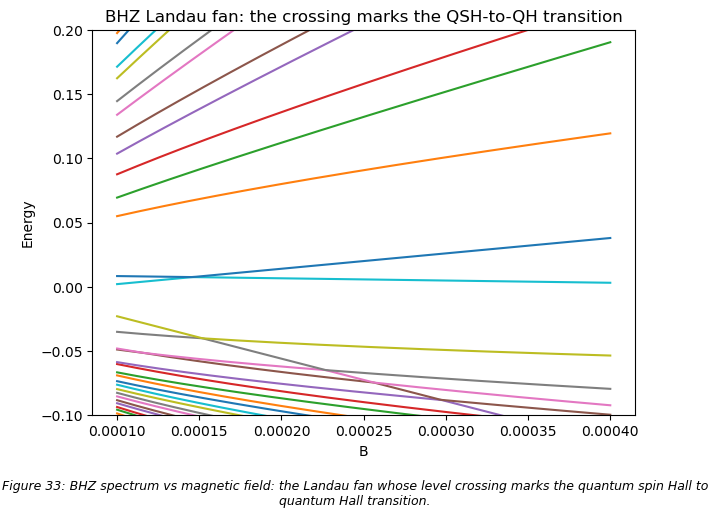

In [4]:
# --- Spectrum of the BHZ model versus magnetic field -------------------------
import kwant, kwant.continuum, numpy as np
from matplotlib import pyplot

hamiltonian_B = """
   + C * identity(4) + M * kron(sigma_0, sigma_z)
   - F * (k_x**2 + k_y**2) * kron(sigma_0, sigma_z)
   - D * (k_x**2 + k_y**2) * kron(sigma_0, sigma_0)
   + A * k_x * kron(sigma_z, sigma_x)
   - A * k_y * kron(sigma_0, sigma_y)
"""

syst_B = kwant.continuum.discretize_landau(hamiltonian_B, N=10).finalized()

params = dict(A=3.645, F=-68.6, D=-51.2, M=-0.01, C=0)
b_values = np.linspace(0.0001, 0.0004, 200)

kwant.plotter.spectrum(syst_B, ('B', b_values), params=params, show=False)
pyplot.ylim(-0.1, 0.2)
pyplot.title("BHZ Landau fan: the crossing marks the QSH-to-QH transition")
show_fig(r'BHZ spectrum vs magnetic field: the Landau fan whose level crossing marks the quantum spin Hall to quantum Hall transition.')